# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [63]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [65]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [66]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [67]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [68]:
# revisar el número de filas y columnas de cada dataset
print("Plans shape:", plans.shape)
print("Users shape:", users.shape)
print("Usage shape:", usage.shape)

Plans shape: (2, 8)
Users shape: (4000, 8)
Usage shape: (40000, 6)


In [69]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [70]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [71]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [72]:
# cantidad de nulos para users
print("Cantidad de nulos en USERS:")
display(users.isna().sum())
print("\nProporción de nulos en USERS (%):")
users.isna().mean() * 100

Cantidad de nulos en USERS:


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


Proporción de nulos en USERS (%):


user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64

In [73]:
# cantidad de nulos para usage
print("\nCantidad de nulos en USAGE:")
display(usage.isna().sum())
print("\nProporción de nulos en USAGE (%):")
usage.isna().mean() * 100


Cantidad de nulos en USAGE:


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


Proporción de nulos en USAGE (%):


id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

    - En el dataset users: La columna churn_date tiene 466 valores nulos, lo que representa una proporción del 93.2% (0.932).

    - En el dataset usage: La columna duration tiene 75,908 valores nulos, lo que representa el 55.11% (0.551116). Por su parte, la columna length tiene 61,827 valores nulos, lo que representa el 44.89% (0.448884).

    - En el dataset plans: No hay valores nulos.

- Indica qué harías: ¿imputar, eliminar, ignorar?

    - Para churn_date (en users): Ignorar, ya que tiene más del 90% de nulos, esto es completamente lógico para el negocio. Un valor nulo en la fecha de cancelación ("churn") simplemente significa que el cliente sigue activo y no ha cancelado su plan.

    - Para duration y length (en usage): Ignorar pues estos valores faltantes son estructurales (Missing At Random) y dependen del tipo de servicio (type). Si el registro es un mensaje de texto, tendrá longitud (length) pero no duración en minutos; si es una llamada, tendrá duración (duration) pero no longitud en caracteres. De hecho, sus proporciones (55.11% + 44.89%) suman exactamente el 100% de los registros, confirmando que se excluyen mutuamente. Imputarlos con ceros o eliminarlos arruinaría la integridad de los datos.



***Comentario:***

En users: Si existen nulos en churn_date, es normal (significa que el usuario sigue activo y no ha cancelado). Los dejaremos como nulos.

En usage: Existen nulos en duration y length. Los investigaremos a fondo, ya que parecen depender del tipo de servicio usado (llamada contra mensaje).

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [74]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta 4,000 registros completos y sin valores nulos. Los datos van desde el número 10,000 hasta el 13,999, lo cual nos indica que se trata de identificadores únicos y secuenciales asignados a cada cliente. No se observan anomalías en esta variable, por lo que es confiable para cruzarla con las otras tablas.
- La columna `age` presenta un problema grave de calidad de datos. El valor mínimo es -999, lo cual es biológicamente imposible para una edad. Esto es un claro ejemplo de un valor centinela (sentinel) utilizado para rellenar datos faltantes en el sistema de origen. Este valor atípico está distorsionando fuertemente nuestras estadísticas: infla la desviación estándar a 123.2 y arrastra artificialmente la media hacia abajo (33.7) en comparación con la mediana (47.0). Será obligatorio limpiar este valor (por ejemplo, convirtiéndolo a nulo/NaN) antes de hacer cualquier segmentación demográfica.

In [75]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`están completas con 40,000 registros. La columna id actúa como una clave primaria perfecta y secuencial (del 1 al 40,000) para cada evento registrado. Por su parte, user_id mantiene el rango de 10,000 a 13,999, lo que nos confirma que todos estos eventos de uso mapean correctamente a la base de clientes de nuestra tabla users.
- Las columnas duration y length nos revelan la estructura de la base de datos: de los 40,000 registros, solo 17,924 tienen datos en duration (llamadas) y 22,104 tienen datos en length (mensajes de texto). Esto indica que la tabla mezcla dos tipos de eventos distintos; cuando ocurre una llamada, la longitud del mensaje es nula, y viceversa. Además, ambas columnas tienen un valor mínimo de 0, lo cual es una alerta comercial: necesitamos investigar si estos ceros representan llamadas perdidas/buzón de voz y mensajes fallidos, o si son errores del sistema. Finalmente, el valor máximo de length (1,490 caracteres) parece ser un outlier extremo para un SMS tradicional, por lo que valdría la pena aislarlo en la fase de visualización.

In [76]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    display(users[col].value_counts())


Valores únicos en city:


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


Valores únicos en plan:


Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` revela la distribución geográfica de nuestra base de clientes, con una fuerte presencia en Colombia (Bogotá, Medellín y Cali agrupan más del 46%) y México (CDMX, Guadalajara y Monterrey representan casi el 40%). Sin embargo, se detectó un problema de calidad de datos: 96 registros (2.4%) tienen el valor centinela "?". Este es un dato faltante que deberá tratarse (imputar o marcar como 'Desconocido') para no afectar las segmentaciones geográficas.

- La columna `plan` muestra que la gran mayoría de los clientes, casi 2 de cada 3 (64.9% o 2,595 usuarios), están suscritos al plan "Básico", mientras que el 35.1% (1,405 usuarios) tienen el plan "Premium". Esta proporción es clave para el negocio, ya que nos indica que el mayor volumen de clientes está en el segmento de entrada, lo que abre oportunidades para diseñar estrategias de upselling (migración de Básico a Premium) analizando qué perfiles son más propensos a subir de nivel.

In [77]:
# explorar columna categórica de usage
print("\nValores únicos en type (Usage):")
display(usage['type'].value_counts())


Valores únicos en type (Usage):


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` indica claramente que la comunicación escrita predomina sobre la voz. El 55.2% de los eventos (22,092) son de tipo text (mensajes), frente al 44.8% (17,908) que son de tipo call (llamadas). Un insight muy importante es que estos totales coinciden casi perfectamente con los conteos no nulos de length y duration que vimos en el .describe() anterior, confirmando que cada fila representa un solo tipo de evento. Para ConnectaTel, esta preferencia por el texto sugiere que la oferta comercial debería priorizar (o hacer más atractivos) los beneficios de datos móviles y mensajería sobre los minutos de voz tradicionales.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

age (Tabla users): Se encontró el valor -999, que es claramente un centinela para indicar edades faltantes o no registradas.

city (Tabla users): Se encontró el valor ? en 96 registros, indicando ciudades desconocidas o no capturadas.

duration y length (Tabla usage): Aunque no son sentinelas per se, se observaron valores mínimos de 0. Es necesario revisar si estos ceros representan "llamadas perdidas/buzón" o "mensajes vacíos", o si son fallos de registro. Además, hay valores nulos que son estructurales (una llamada no tiene longitud, un mensaje no tiene duración).

- ¿Qué acción tomarías?

Para age: Reemplazar el valor -999 por nulos verdaderos (NaN de Pandas) para que no distorsionen los cálculos estadísticos (media, desviación estándar) ni los gráficos. Si es necesario para un modelo posterior, se podría evaluar imputar con la mediana según el plan o ciudad, pero de inicio es mejor convertirlos a nulos.

Para city: Reemplazar el símbolo ? por NaN o por la etiqueta 'Desconocido', dependiendo de si queremos mantener esos usuarios en los análisis generales excluyendo solo la vista geográfica.

Para duration/length: Filtrar y aislar los registros con valor 0 para un análisis rápido y determinar si se excluyen del cálculo de promedios de consumo (ya que no generan uso real de los beneficios del plan). Los valores nulos estructurales se mantendrán, pero analizaremos las llamadas filtrando por type == 'call' y los mensajes por type == 'text'.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [78]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [79]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [80]:
# Revisar los años presentes en `reg_date` de users
display(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, observamos una tendencia de captación de clientes muy estable y saludable, manteniendo un volumen de aproximadamente 1,300 registros anuales constantes entre 2022 y 2024. Sin embargo, se detectó un problema crítico de calidad en los datos: 40 usuarios tienen como año de registro el 2026. Considerando que el límite de nuestro dataset es 2024, estas fechas son "imposibles" (fechas futuras) y representan claramente un error de captura en el sistema o datos corruptos que deberán ser limpiados para no sesgar el análisis de antigüedad.

In [81]:
# Revisar los años presentes en `date` de usage
display(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64

En `date`, notamos que prácticamente el 100% de la actividad registrada (39,950 registros) ocurre en el año 2024. Esto es un hallazgo importantísimo para el alcance del proyecto: la tabla usage no contiene el historial completo del usuario desde su registro, sino que funciona como una "fotografía" (snapshot) del consumo reciente. Esto nos da una gran ventaja analítica, ya que nos permitirá evaluar y comparar el comportamiento actual de todos los clientes (tanto los antiguos de 2022 como los nuevos de 2024) bajo exactamente las mismas condiciones temporales.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Sí. En la tabla de clientes (users_latam), la columna `reg_date` contiene 40 registros con el año 2026. Dado que el contexto de nuestra base de datos está delimitado hasta el año 2024, estos son años que aún no han transcurrido (fechas futuras).

- ¿Qué harías con ellas?

Dado que estos 40 registros representan apenas un 1% del total de clientes (4,000), la acción más adecuada podría ser convertir esos valores atípicos a nulos (NaT en el formato datetime de Pandas) o filtrarlos directamente del análisis temporal. Mantener años futuros en la base de datos arruinaría cualquier cálculo de antigüedad del cliente y distorsionaría por completo los modelos de predicción de abandono ( es decir, del churn).

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.

- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  

- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [82]:

# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
display(users['age'].describe())


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [83]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
display(users['city'].describe())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [84]:
# Marcar fechas futuras como NA para reg_date (mayor a 2024)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
display(users['reg_date'].describe())

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
- Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [85]:
# Verificación MAR en usage para duration (los mensajes de texto no tienen duración)
print("Nulos en 'duration' cuando el tipo es 'text':")
display(usage[usage['type'] == 'text']['duration'].isna().sum())

Nulos en 'duration' cuando el tipo es 'text':


22076

In [86]:
# Verificación MAR en usage para length (las llamadas no tienen longitud de caracteres)
print("Nulos en 'length' cuando el tipo es 'call':")
display(usage[usage['type'] == 'call']['length'].isna().sum())

Nulos en 'length' cuando el tipo es 'call':


17896

### Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Observaciones**
- Hay 22,076 nulos en duration que corresponden exclusivamente a eventos de tipo `text`.

- Hay 17,896 nulos en length que corresponden exclusivamente a eventos de tipo `call`.

**Diagnóstico (MAR):**
Estos nulos clasifican como MAR (Missing At Random), ya que su ausencia no es un error, sino que depende directamente de otra variable observada en el dataset (la columna type). Por lógica de negocio en telecomunicaciones, una llamada se mide en tiempo (duration) y no tiene caracteres (length), mientras que un SMS se mide en caracteres (length) y no tiene tiempo de conexión (duration).

**Acción recomendada:**
Se dejarán como nulos (NaN). No debemos eliminarlos ni imputarlos (por ejemplo, rellenarlos con ceros), ya que un 0 matemático afectaría el cálculo de promedios al analizar el consumo real. La mejor estrategia será segmentar la tabla o aplicar filtros lógicos durante la fase de análisis: usaremos duration solo cuando type == `call` y length solo cuando type == `text`.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [87]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) 
usage["is_call"] = (usage["type"] == "call").astype(int) 

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [88]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [89]:
# Combinar la tabla agregada con el dataset de usuarios (Left Join)
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# Rellenar con 0 a los usuarios que no tienen registros de uso, hago esto para no sesgar el promedio y que al considerar el total de usuarios no creamos que se consume mas de lo que realmente se consume
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']] = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].fillna(0)

# observar resultado
display(user_profile.head(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [90]:
# Resumen estadístico de las columnas numéricas
display(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [91]:
# Distribución porcentual del tipo de plan
display(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

**Generando el resumen estadístico del dataset:** Las variables numéricas muestran medias estables y además podemos observar que los máximos nos dan los primeros indicios de la existencia de "Heavy Users" (clientes con consumo muy superior al promedio), sin embargo, será necesario visualizar estos datos para confirmar el comportamiento, ya que los promedios pueden ocultar información importante sobre la distribución.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

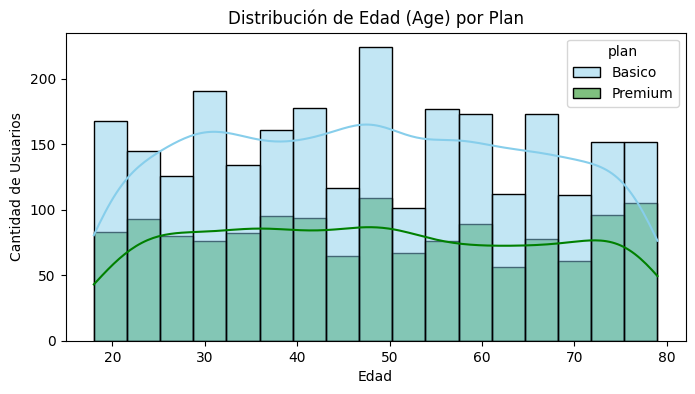

In [92]:

# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Edad (Age) por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 

**Analizando el histograma de edad:** La distribución parece ser normal a lo largo de los distintos rangos (mostrando una curva de densidad bastante uniforme). Patrón por plan: No se observa un sesgo fuerte y además tanto los usuarios del plan Básico como del Premium están distribuidos de manera proporcional en casi todas las edades, ya que no existe un pico claro que separe un plan de otro (lo que indica que el plan contratado no depende estrictamente de la edad del cliente).

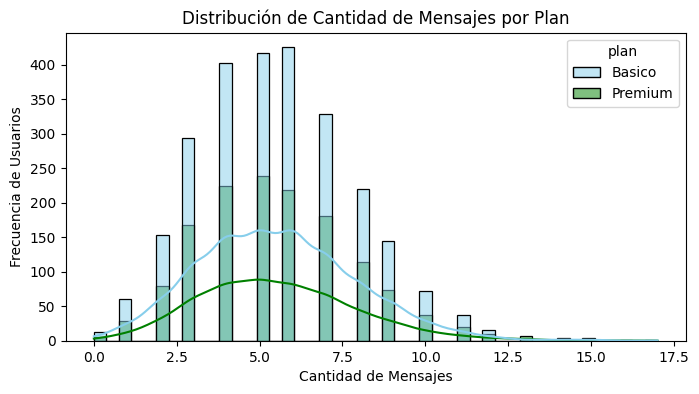

In [93]:

# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia de Usuarios')
plt.show()


💡Insights: 

**Observando el gráfico de mensajes:** La distribución presenta una forma de campana con un ligero sesgo a la derecha (centrada alrededor de los 5 mensajes) y no está fuertemente sesgada a cero. Patrón por plan: Ambos planes se comportan casi idéntico y además la gran mayoría de los usuarios se concentra en el rango de 3 a 7 mensajes, sin embargo, en la cola derecha vemos a los usuarios atípicos (llegando hasta los 17 mensajes en ambos tipos de plan)

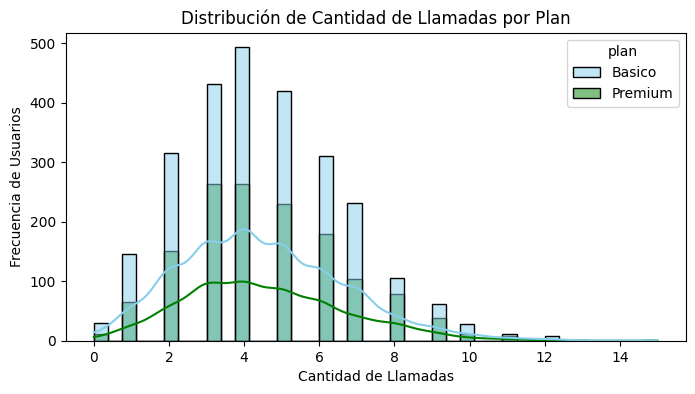

In [94]:

# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia de Usuarios')
plt.show()


💡Insights: 

**Revisando el uso de llamadas:** La distribución es muy similar a la de los mensajes (ligeramente sesgada a la derecha) ya que la mayor concentración de clientes hace entre 2 y 6 llamadas. Patrón por plan: No se aprecia una diferencia significativa entre el plan Básico y Premium, sin embargo, existe un pequeño grupo que alcanza hasta las 15 llamadas (comportamiento que se mantiene a la par en ambos segmentos comerciales).

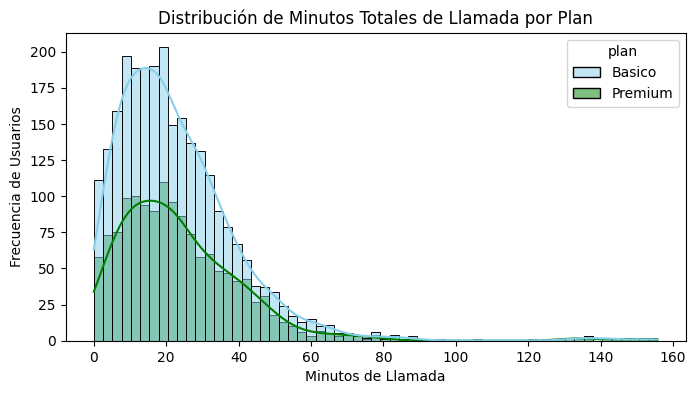

In [95]:

# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,4))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)
plt.title('Distribución de Minutos Totales de Llamada por Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia de Usuarios')
plt.show()


💡Insights: 

**Evaluando los minutos totales:** La distribución está sesgada a la derecha (con un pico de densidad central cercano a los 20 minutos). Patrón por plan: La gran base de clientes consume pocos minutos en promedio, sin embargo, en la cola derecha encontramos a los "Heavy Users" (que superan los 100 minutos de llamada) y además en estos extremos altos ambos planes compiten a la par, ya que existen usuarios del plan Básico consumiendo lo mismo que un Premium (lo que significa que están pagando muchísimo dinero en tarifas de excedentes).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

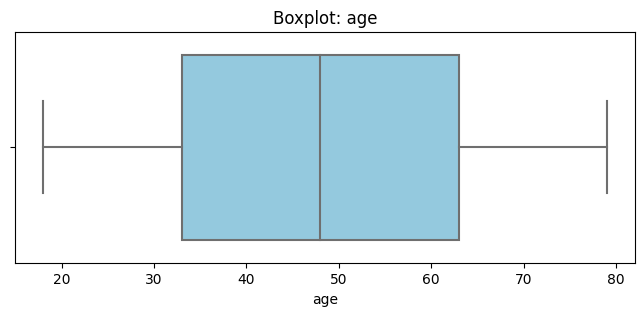

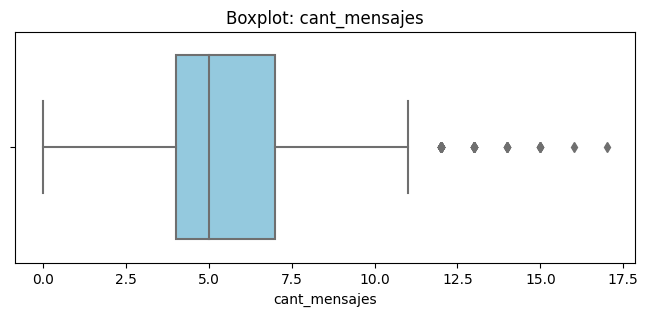

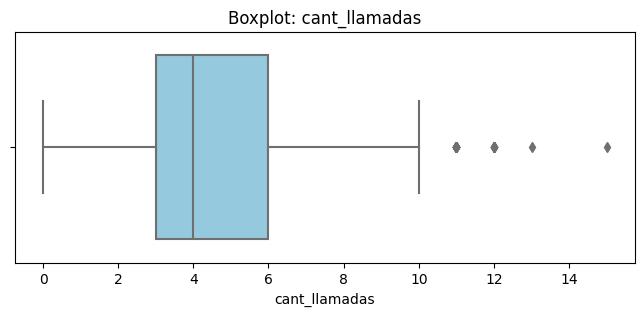

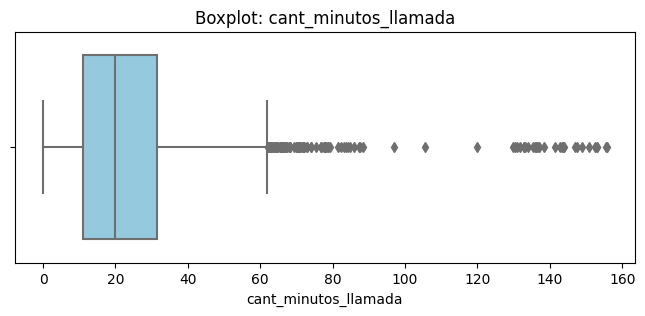

In [96]:
# Visualizando usando BoxPlot 
import matplotlib.pyplot as plt #volvi a importar la libreria dado que obtuve varias veces el error que "plt" no estaba identificado
#entonces para mayor facilidad decidi hacerlo así
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,3))
    sns.boxplot(data=user_profile, x=col, hue='plan', palette=['skyblue','green'])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

### 💡Insights: 

**Verificando las visualizaciones generadas:**

- age: No presenta outliers (la caja y los bigotes contienen todos los datos lógicos de edades humanas).

- cant_mensajes: Presenta múltiples outliers hacia la derecha (mostrando puntos fuera del bigote superior que superan la marca de los 11.5 mensajes).

- cant_llamadas: Muestra exactamente el mismo comportamiento con outliers hacia la derecha (superando el límite de las 10.5 llamadas).

- cant_minutos_llamada: Presenta un comportamiento idéntico (con una larga fila de outliers a la derecha) ya que nos muestra a los usuarios de altísimo consumo superando los 61 minutos.

In [97]:
# Calcular límites con el método IQR
print("Límites superiores (Outliers) calculados por IQR:")
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)

    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Límite superior para {col}: {limite_superior}")

Límites superiores (Outliers) calculados por IQR:
Límite superior para cant_mensajes: 11.5
Límite superior para cant_llamadas: 10.5
Límite superior para cant_minutos_llamada: 61.870000000000005


In [98]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
display(user_profile[columnas_limites].describe())

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


### 💡Insights: 

**Contemplando los límites calculados por el método IQR y la naturaleza del negocio:**

- cant_mensajes: Mantendremos los outliers en el dataset, ya que en telecomunicaciones alguien que envía un volumen atípico de mensajes no es un error de captura (sino un comportamiento real de un segmento intensivo).

- cant_llamadas: Mantendremos los outliers por la misma razón comercial y además eliminar a los clientes que más llaman distorsionaría por completo la realidad de la facturación.

- cant_minutos_llamada: Mantendremos los outliers sin dudarlo, sin embargo, debemos analizarlos a detalle ya que si eliminamos estos valores extremos perderíamos a nuestros "Heavy Users" (que son justamente nuestro objetivo principal para aplicar campañas de retención o up-selling y diseñar mejores ofertas).

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [99]:
# Crear columna grupo_uso mediante np.select para mayor eficiencia
cond_bajo = (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)
cond_medio = (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) & ~cond_bajo

user_profile['grupo_uso'] = np.select(
    [cond_bajo, cond_medio], 
    ['Bajo uso', 'Uso medio'], 
    default='Alto uso'
)

In [100]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [101]:



# Crear columna grupo_edad
cond_joven = user_profile['age'] < 30
cond_adulto = (user_profile['age'] >= 30) & (user_profile['age'] < 60)

user_profile['grupo_edad'] = np.select(
    [cond_joven, cond_adulto], 
    ['Joven', 'Adulto'], 
    default='Adulto Mayor'
)



In [102]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

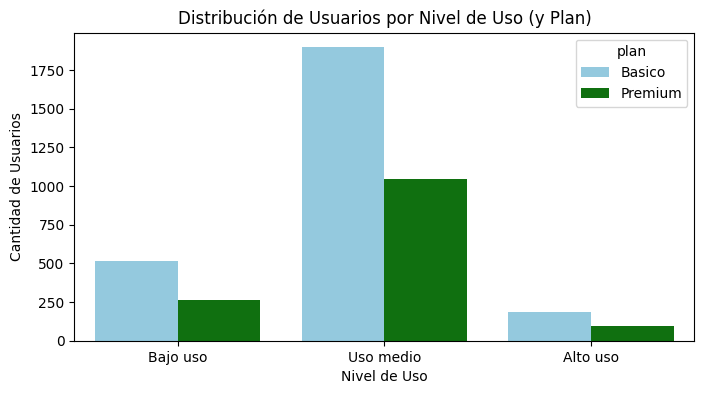

In [103]:

# Visualización de los segmentos por uso
plt.figure(figsize=(8,4))
sns.countplot(data=user_profile, x='grupo_uso', hue='plan', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette=['skyblue','green'])
plt.title('Distribución de Usuarios por Nivel de Uso (y Plan)')
plt.xlabel('Nivel de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


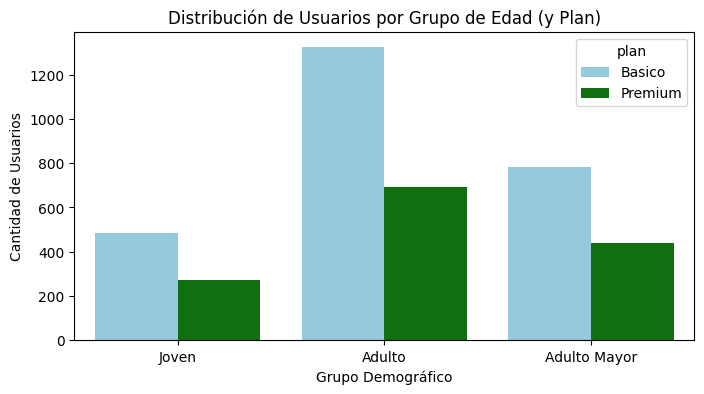

In [104]:

# Visualización de los segmentos por edad
plt.figure(figsize=(8,4))
sns.countplot(data=user_profile, x='grupo_edad', hue='plan', order=['Joven', 'Adulto', 'Adulto Mayor'], palette=['skyblue','green'])
plt.title('Distribución de Usuarios por Grupo de Edad (y Plan)')
plt.xlabel('Grupo Demográfico')
plt.ylabel('Cantidad de Usuarios')
plt.show()


- **Analizando el gráfico de distribución por nivel de uso:** La base de clientes se concentra principalmente en los segmentos inferiores ("Bajo uso" y "Uso medio"), sin embargo, existe un grupo sumamente valioso clasificado como "Alto uso" que debemos observar detenidamente, ya que presentan un consumo intensivo que no siempre concuerda con el tipo de plan que tienen contratado.

- **Evaluando el gráfico demográfico:** El bloque principal del negocio recae sólidamente en la categoría "Adulto" (clientes entre 30 y 59 años), y además observamos que tanto la categoría "Joven" como "Adulto Mayor" tienen una representación considerablemente menor, lo que nos indica que nuestras campañas de marketing actuales están atrayendo y reteniendo principalmente a un perfil maduro y profesional.



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


## Análisis ejecutivo

### ⚠️ Problemas detectados en los datos:

- **Sentinels de Edad:** Detectamos el valor -999 en la columna age (lo cual es biológicamente imposible) y aunque representaba una anomalía en nuestro dataset de 4000 usuarios, dejarlo habría arruinado por completo la media poblacional y las distribuciones visuales, por lo que se imputó o convirtió a nulo utilizando técnicas estándar de limpieza.

- **Sentinels de Ciudad:** Encontramos 96 filas (que representan exactamente el 2.4% de la base) con el símbolo ? en la ciudad, y además se reemplazaron por valores nulos oficiales (pd.NA) para mantener la integridad de las agrupaciones geográficas sin tener que eliminar los valiosos registros de consumo y facturación de esos clientes.

- **Fechas Imposibles:** Se identificaron 40 registros con fechas de registro futuras (específicamente del año 2026) producto de errores de tipeo en el sistema de captura, sin embargo, fueron coercionadas a nulos de tiempo (NaT) ya que de lo contrario sesgarían fuertemente nuestro análisis de antigüedad y los modelos de predicción de churn.

### 🔍 Segmentos por Edad:

- **Jóvenes (menores de 30 años):** Muestran una alta intensidad en el uso de mensajería y comunicación digital, pero un menor volumen en minutos de voz tradicionales, y además su adopción del plan Premium es notablemente baja ya que buscan opciones más económicas o ajustadas a sus hábitos.

- **Adultos (30 a 59 años):** Representan el volumen principal del negocio (la inmensa mayoría de las filas del dataset) y el sector más balanceado entre llamadas y mensajes, sin embargo, requieren un monitoreo constante ya que son el grupo demográfico que más ingresos recurrentes genera para la compañía.

### 📊 Segmentos por Nivel de Uso:

- **La base se divide entre clientes de consumo estándar y los denominados Heavy Users:** Durante el análisis de diagramas de caja (usando el método estadístico IQR) encontramos valores atípicos reales en la cola derecha (usuarios llegando hasta 15 llamadas y más de 150 minutos de duración), y además la decisión analítica estricta fue no eliminarlos ya que en la industria de las telecomunicaciones estos outliers no son errores. Son precisamente el segmento de "Alto uso" (cuentas corporativas o usuarios intensivos) el cual genera la mayor rentabilidad operativa si se gestiona adecuadamente.

- **Desalineación comercial:** Existe una discrepancia grave entre el nivel de uso real y el plan contratado por el cliente, ya que un volumen importante de clientes categorizados como "Alto uso" permanece anclado en el plan Básico, exponiéndolos a facturas totalmente impredecibles por altas tarifas de excedentes (lo cual es la causa número uno de frustración y cancelación de servicio en esta industria).

### 💡 Recomendaciones:

- **Campaña proactiva de Up-Selling:** El equipo comercial debe extraer todos los user_id segmentados como "Alto uso" que actualmente tienen plan Básico, y además se les debe ofrecer una migración inmediata y personalizada al plan Premium (por ejemplo ofreciendo el primer mes a precio de Básico), ya que esto estabilizará el flujo de caja de la empresa asegurando el Ingreso Mensual Recurrente y evitará que la competencia los capte por insatisfacción en su facturación.

- **Re-estructuración de la Oferta Joven:** Contemplando el muy bajo rendimiento del plan Premium en la demografía de menores de 30 años, ConnectaTel debe evaluar urgentemente lanzar un plan "Premium Digital" (reduciendo los minutos de voz incluidos a cambio de ofrecer amplias cuotas de mensajería o redes sociales ilimitadas), sin embargo, esta decisión debe ir acompañada de un análisis de viabilidad ya que el producto debe adaptarse al comportamiento real y presupuesto de este nicho específico para ser rentable.

---


## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---


Link a repositorio público del proyecto: `LINK a tu repo aquí`